# LLaMA Factory를 이용한 QLoRA 파인튜닝 실습

## 📚 강의 개요

이 노트북에서는 **LLaMA Factory** 프레임워크를 사용하여 대규모 언어 모델(LLM)을 **QLoRA** 기법으로 파인튜닝하는 방법을 학습합니다.

### 학습 목표
- LLaMA Factory의 개념과 사용법 이해
- LLaMA Factory CLI 활용
- Web UI를 통한 No-Code 파인튜닝
- 의료 도메인 데이터셋을 활용한 실전 파인튜닝

### 참고 자료
- [LLaMA Factory 공식 문서](https://llamafactory.readthedocs.io/en/latest/)
- [SK Devocean - No-Code LLM 파인튜닝](https://devocean.sk.com/blog/techBoardDetail.do?ID=166098)
- [LLaMA Factory GitHub](https://github.com/hiyouga/LLaMA-Factory)

---


## 1. LLaMA Factory란?

### 1.1 개요

**LLaMA Factory**는 코드 작성 없이도 다양한 LLM을 효율적으로 파인튜닝할 수 있는 통합 프레임워크입니다.

### 1.2 주요 특징

#### ✅ No-Code 지원
- **Web UI (Gradio)**: 코드 없이 브라우저에서 모델 학습
- **CLI**: 명령줄 인터페이스로 간편한 실행  
- **Python API**: 프로그래밍 방식의 세밀한 제어

#### ✅ 다양한 모델 지원
- LLaMA, Mistral, Qwen, Gemma 등 100+ 모델
- Hugging Face Hub와 완벽 통합

#### ✅ 효율적인 학습 기법
- **QLoRA**: 양자화 + LoRA (4-bit)
- **LoRA**: Low-Rank Adaptation
- **Full Fine-tuning**: 전체 파라미터 학습

#### ✅ 고급 기능
- RLHF, DPO, PPO 지원
- 멀티 GPU 학습
- 다양한 형식으로 내보내기 (GGUF, AWQ, GPTQ)

### 1.3 LLaMA Factory의 장점

| 장점 | 설명 |
|------|------|
| 🚀 **빠른 시작** | 복잡한 코드 없이 즉시 시작 |
| 💰 **비용 효율** | QLoRA로 적은 GPU 메모리로 학습 |
| 🎯 **사용 편의성** | Web UI로 직관적인 설정 |
| 🔧 **유연성** | CLI, API, UI 모두 지원 |
| 📊 **통합 관리** | 데이터-학습-평가-배포 원스톱 |

---


## 2. QLoRA (Quantized Low-Rank Adaptation)

### 2.1 QLoRA란?

**QLoRA**는 4-bit 양자화와 LoRA를 결합하여 메모리 효율적으로 대규모 모델을 파인튜닝하는 기법입니다.

### 2.2 메모리 비교

```
전통적 Fine-tuning vs QLoRA (7B 모델 기준)

Full Fine-tuning:     ~28GB GPU 메모리 필요
LoRA (16-bit):        ~14GB GPU 메모리 필요  
QLoRA (4-bit):        ~6GB GPU 메모리 필요  ✅
```

### 2.3 주요 하이퍼파라미터

| 파라미터 | 설명 | 권장값 |
|---------|------|--------|
| `lora_rank` | LoRA 어댑터 크기 | 8, 16, 32 |
| `lora_alpha` | 스케일링 팩터 | 16, 32, 64 |
| `lora_dropout` | 드롭아웃 비율 | 0.05, 0.1 |
| `lora_target` | 적용할 레이어 | all, q_proj,v_proj |

---


## 3. 환경 설정 및 확인

### 3.1 패키지 확인


In [ ]:
# LLaMA Factory 및 환경 확인
try:
    import llamafactory
    print(f"✅ LLaMA Factory: {llamafactory.__version__}")
    
    import torch
    print(f"✅ PyTorch: {torch.__version__}")
    print(f"✅ CUDA Available: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
        print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f}GB")
    
    print("\n🎉 모든 패키지가 정상 설치되었습니다!")
except Exception as e:
    print(f"❌ 오류: {e}")
    print("\n설치 명령어: pip install -r ../requirements.txt")


### 3.2 LLaMA Factory CLI 확인


In [ ]:
!llamafactory-cli version


---

## 4. 데이터셋 준비

### 4.1 데이터 로드 및 확인

의료 상담 데이터셋(illnesses.csv)을 LLaMA Factory가 인식할 수 있는 형식으로 변환합니다.


In [ ]:
import pandas as pd
import json
from pathlib import Path
from sklearn.model_selection import train_test_split

# 데이터 로드
df = pd.read_csv("data/illnesses.csv")
print(f"📊 총 {len(df)}개 샘플")
print(f"\n샘플 미리보기:")
print(df[['user_input', 'reference']].head(2))

# 학습/검증 분할
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
print(f"\n✅ 학습: {len(train_df)}, 검증: {len(val_df)}")


### 4.2 Alpaca 형식으로 변환

LLaMA Factory는 Alpaca 형식(instruction, input, output)을 사용합니다.


In [ ]:
# Alpaca 형식으로 변환
def to_alpaca(dataframe):
    data = []
    for _, row in dataframe.iterrows():
        data.append({
            "instruction": "당신은 소아청소년과 전문의입니다. 다음 질문에 답변해주세요.",
            "input": row['user_input'],
            "output": row['reference']
        })
    return data

train_data = to_alpaca(train_df)
val_data = to_alpaca(val_df)

# 저장
Path("data").mkdir(exist_ok=True)
with open("data/medical_train.json", "w", encoding="utf-8") as f:
    json.dump(train_data, f, ensure_ascii=False, indent=2)
with open("data/medical_val.json", "w", encoding="utf-8") as f:
    json.dump(val_data, f, ensure_ascii=False, indent=2)

print(f"✅ 데이터 저장 완료")
print(f"   data/medical_train.json ({len(train_data)} 샘플)")
print(f"   data/medical_val.json ({len(val_data)} 샘플)")


### 4.3 dataset_info.json 생성

LLaMA Factory에 데이터셋을 등록합니다.


In [ ]:
# dataset_info.json 생성
dataset_info = {
    "medical_train": {
        "file_name": "medical_train.json",
        "formatting": "alpaca"
    },
    "medical_val": {
        "file_name": "medical_val.json",
        "formatting": "alpaca"
    }
}

with open("data/dataset_info.json", "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, ensure_ascii=False, indent=2)

print("✅ dataset_info.json 생성 완료")
print(json.dumps(dataset_info, ensure_ascii=False, indent=2))


---

## 5. LLaMA Factory CLI로 학습하기

### 5.1 학습 명령어

**기본 형식:**
```bash
llamafactory-cli train \
    --model_name_or_path MODEL \
    --dataset DATASET \
    --output_dir OUTPUT \
    [옵션...]
```

### 5.2 QLoRA 학습 실행


In [1]:
from dotenv import load_dotenv

# .env 파일에 기록된 환경 변수를 시스템으로 불러옵니다.
load_dotenv() 

True

> LLaMA Factory CLI로 QLoRA 학습 실행   
> 아래 명령어를 터미널에서 실행하세요

```shell
!llamafactory-cli train \
    --stage sft \                                       # 학습 단계 설정 (Supervised Fine-Tuning)
    --do_train true \                                   # 학습 실행 여부 설정
    --load_best_model_at_end true \                     # 학습 종료 후 가장 결과(Loss 등)가 좋았던 체크포인트를 최종 모델로 로드
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \   # 베이스가 되는 사전 학습된 모델 경로
    --dataset medical_train \                           # dataset_info.json에 등록된 학습용 데이터셋 별칭
    --dataset_dir data \                                # 데이터셋 설정 파일과 데이터가 들어있는 폴더
    --template qwen \                                   # Qwen 모델의 대화 양식(Template) 적용
    --finetuning_type lora \                            # LoRA(Low-Rank Adaptation) 미세조정 방식 사용
    --lora_target all \                                 # 모델의 모든 선형 레이어에 LoRA 적용
    --output_dir outputs/medical_qwen_qlora \           # 학습된 모델과 체크포인트가 저장될 경로
    --overwrite_output_dir true \                       # 결과 폴더가 이미 있으면 덮어쓰기
    --eval_strategy steps \                             # 평가 수행 방식 (일정 스텝마다 평가)
    --save_strategy steps \                             # 저장 수행 방식 (일정 스텝마다 저장)
    --eval_steps 100 \                                  # 100스텝마다 평가 수행 (load_best_model_at_end를 위해 필수)
    --save_steps 100 \                                  # 100스텝마다 체크포인트 저장 (eval_steps와 일치 권장)
    --num_train_epochs 3 \                              # 전체 데이터를 총 3번 반복하여 학습
    --per_device_train_batch_size 4 \                   # 그래픽카드(GPU) 1개당 한 번에 학습할 데이터 개수
    --gradient_accumulation_steps 4 \                   # 가중치 업데이트 전 4번의 스텝을 누적 (실제 배치 사이즈 = 4 * 4 = 16 효과)
    --learning_rate 2e-4 \                              # 모델이 가중치를 조정하는 속도(학습률)
    --lr_scheduler_type cosine \                        # 학습률을 코사인 곡선 형태로 서서히 감소시킴
    --warmup_ratio 0.1 \                                # 초기 학습 안정화를 위해 학습률을 서서히 올리는 구간 비율
    --logging_steps 10 \                                # 10스텝마다 로그(현재 Loss 등)를 화면에 출력
    --val_size 0.1 \                                    # 전체 학습 데이터 중 10%를 검증(Validation)용으로 자동 분리
    --quantization_bit 4 \                              # 4비트 양자화(QLoRA)를 사용하여 비디오 메모리(VRAM) 절약
    --fp16 true                                         # 16비트 부동소수점 연산으로 학습 속도 향상
```

In [9]:
!llamafactory-cli train \
    --stage sft \
    --do_train true \
    --load_best_model_at_end true \
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \
    --dataset medical_train \
    --dataset_dir data \
    --template qwen \
    --finetuning_type lora \
    --lora_target all \
    --output_dir outputs/medical_qwen_qlora \
    --overwrite_output_dir true \
    --eval_strategy steps \
    --save_strategy steps \
    --eval_steps 100 \
    --save_steps 100 \
    --num_train_epochs 3 \
    --per_device_train_batch_size 4 \
    --gradient_accumulation_steps 4 \
    --learning_rate 2e-4 \
    --lr_scheduler_type cosine \
    --warmup_ratio 0.1 \
    --logging_steps 10 \
    --val_size 0.1 \
    --quantization_bit 4 \
    --fp16 true

/usr/local/lib/python3.11/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[WARNING|2026-01-07 02:13:41] llamafactory.hparams.parser:148 >> We recommend enable `upcast_layernorm` in quantized training.
[INFO|2026-01-07 02:13:41] llamafactory.hparams.parser:464 >> Process rank: 0, world size: 1, device: cuda:0, distributed training: False, compute dtype: torch.float16
[INFO|tokenization_utils_base.py:2095] 2026-01-07 02:13:41,966 >> loading file vocab.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/vocab.json
[INFO|tokenization_utils_base.py:2095] 2026-01-07 02:13:41,967 >> loading file merges.txt from cache at /root/.cache/huggingface/hub/models--Qwen--Q

---

## 6. LLaMA Factory Web UI 사용하기

### 6.1 Web UI 실행

터미널에서 다음 명령어로 Web UI를 실행합니다:

```bash
llamafactory-cli webui
```

브라우저에서 `http://localhost:7860` 접속

### 6.2 Web UI 사용 가이드

#### Train 탭에서 설정:
1. **Model** 선택: `Qwen/Qwen2.5-1.5B-Instruct`
2. **Finetuning method**: `lora` 선택
3. **Dataset**: `medical_train` 선택
4. **LoRA config**:
   - rank: 16
   - alpha: 32
   - target: all
5. **Quantization**: 4-bit 선택
6. **Training params**:
   - epochs: 3
   - batch size: 4
   - learning rate: 2e-4
7. **Start** 버튼 클릭!

#### Chat 탭에서 테스트:
- 학습한 모델 선택
- 어댑터 경로 지정
- 실시간 대화 테스트

---


## 7. 학습된 모델로 추론하기

### 7.1 CLI로 추론


In [ ]:
print("💬 LLaMA Factory CLI 추론 명령어:")
print("""
llamafactory-cli chat \
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \
    --adapter_name_or_path outputs/medical_qwen_qlora \
    --template qwen \
    --finetuning_type lora \
    --quantization_bit 4
""")


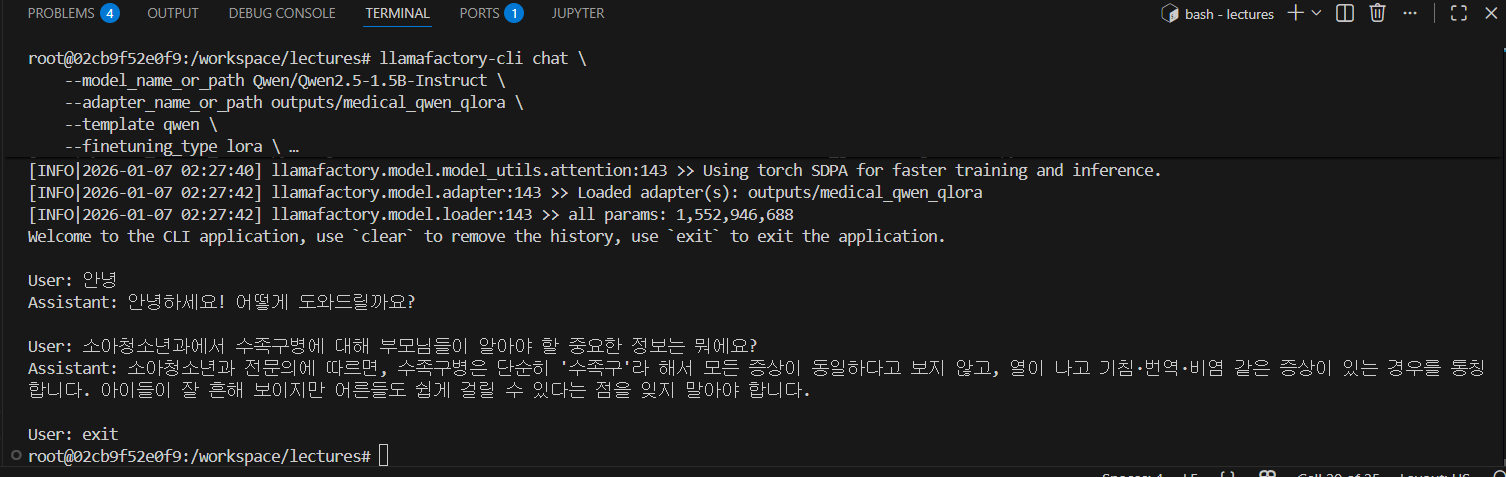

---

## 8. 모델 내보내기

### 8.1 LoRA 어댑터 병합


In [ ]:
print("📤 모델 병합 및 내보내기:")
print("""
llamafactory-cli export \\
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \\
    --adapter_name_or_path outputs/medical_qwen_qlora \\
    --template qwen \\
    --finetuning_type lora \\
    --export_dir models/medical_qwen_merged \\
    --export_size 2 \\
    --export_legacy_format False
""")


In [11]:
!llamafactory-cli export \
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \
    --adapter_name_or_path outputs/medical_qwen_qlora \
    --template qwen \
    --finetuning_type lora \
    --export_dir outputs/medical_qwen_merged \
    --export_size 2 \
    --export_device cpu \
    --export_legacy_format false

/usr/local/lib/python3.11/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[INFO|tokenization_utils_base.py:2095] 2026-01-07 02:30:13,627 >> loading file vocab.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/vocab.json
[INFO|tokenization_utils_base.py:2095] 2026-01-07 02:30:13,627 >> loading file merges.txt from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/merges.txt
[INFO|tokenization_utils_base.py:2095] 2026-01-07 02:30:13,627 >> loading file tokenizer.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1ad

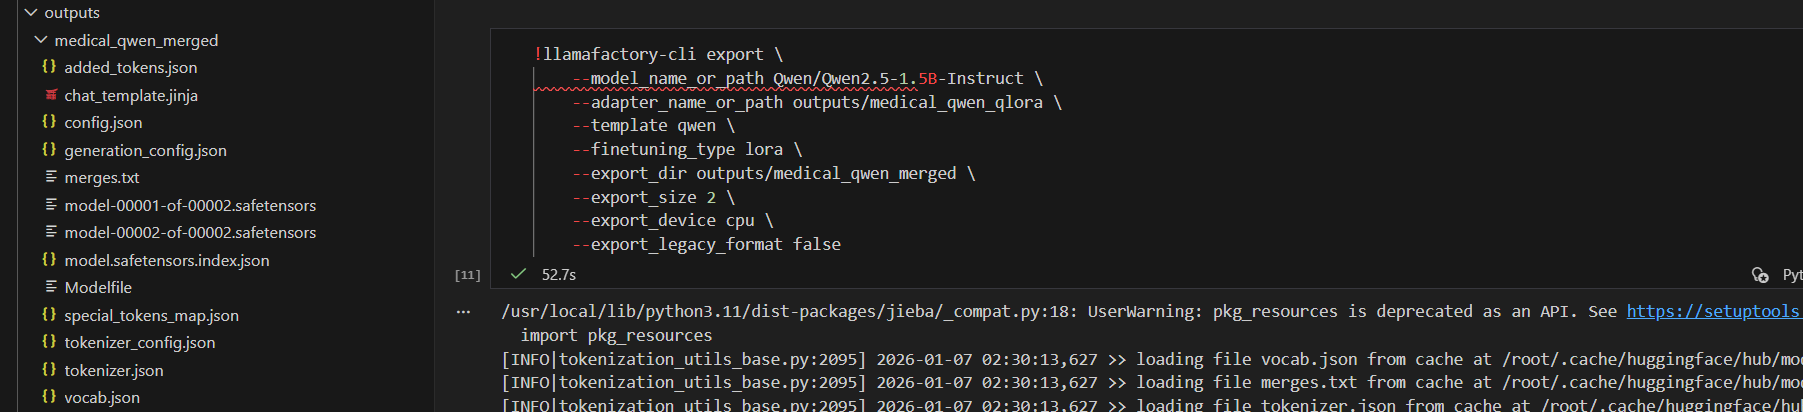

---

## 9. 실전 팁 및 문제 해결

### 9.1 주요 명령어 모음

```bash
# 학습
llamafactory-cli train [옵션]

# 추론/대화
llamafactory-cli chat [옵션]

# Web UI
llamafactory-cli webui

# 모델 내보내기
llamafactory-cli export [옵션]

# 평가
llamafactory-cli eval [옵션]

# 버전 확인
llamafactory-cli version
```

### 9.2 하이퍼파라미터 가이드

| 파라미터 | 작은 값 | 큰 값 | 권장 |
|---------|--------|-------|------|
| lora_rank | 메모리↓ | 성능↑ | 8-32 |
| batch_size | 메모리↓ | 안정↑ | 4-16 |
| learning_rate | 안정 | 빠름 | 2e-4 |
| epochs | 빠름 | 과적합↑ | 3-5 |

### 9.3 메모리 부족 시

```bash
# 1. 배치 크기 줄이기
--per_device_train_batch_size 1

# 2. LoRA 랭크 줄이기
--lora_rank 8

# 3. 시퀀스 길이 줄이기
--cutoff_len 256

# 4. 더 작은 모델 사용
--model_name_or_path Qwen/Qwen2.5-0.5B-Instruct
```

### 9.4 주의사항

⚠️ **데이터**: 최소 100개 이상의 고품질 샘플  
⚠️ **과적합**: 검증 손실 모니터링  
⚠️ **저장**: LoRA 어댑터 + 베이스 모델 함께 보관  
⚠️ **라이선스**: 모델 사용 조건 확인

---


## 10. 요약 및 다음 단계

### 10.1 학습 내용 요약

이번 강의에서 배운 내용:

1. ✅ **LLaMA Factory 소개**
   - No-Code LLM 파인튜닝 프레임워크
   - CLI, Web UI, Python API 지원

2. ✅ **QLoRA 이해**
   - 4-bit 양자화 + LoRA
   - 메모리 효율적 파인튜닝

3. ✅ **실습 완료**
   - 의료 데이터셋 준비 (Alpaca 형식)
   - dataset_info.json 등록
   - CLI/Web UI로 학습 실행
   - 학습된 모델로 추론

4. ✅ **실전 활용**
   - 주요 CLI 명령어
   - 하이퍼파라미터 튜닝
   - 문제 해결 방법

### 10.2 빠른 시작 체크리스트

```bash
# 1. 데이터 준비
✅ CSV를 Alpaca 형식으로 변환
✅ dataset_info.json 생성

# 2. 학습 실행 (둘 중 하나)
✅ CLI: llamafactory-cli train [옵션]
✅ Web UI: llamafactory-cli webui

# 3. 추론
✅ CLI: llamafactory-cli chat [옵션]
✅ Web UI의 Chat 탭 사용

# 4. 모델 내보내기 (선택)
✅ llamafactory-cli export [옵션]
```

### 10.3 다음 단계

#### 🚀 추가 학습
- **RLHF/DPO**: 선호도 기반 학습
- **멀티 GPU**: 분산 학습
- **GGUF 양자화**: 경량화

#### 📚 참고 자료
- [LLaMA Factory GitHub](https://github.com/hiyouga/LLaMA-Factory)
- [공식 문서](https://llamafactory.readthedocs.io/)
- [SK Devocean 블로그](https://devocean.sk.com/blog/techBoardDetail.do?ID=166098)

---

## 🎉 수고하셨습니다!

LLaMA Factory로 여러분만의 도메인 특화 모델을 만들어보세요!

**Happy Fine-tuning! 🚀**
